# Documentation for applying UNOX on the CO data


Author: Daniel Sequeira \
Supervisor: Dylan Jones \
Date: 14 August 2025

## This document will walk you through how to run the Unet model for NOx (UNOX) on the CO data and some useful background info

So far we have gotten Stage 1 has to work. We have yet to touch stage 2.

Files' Location: 
/users/jk/20/dbj/ESSDA/GC_v14.1.1/gc_2x25_47L_merra2_tagCO/OutputDir

HEMCO\
File extension: .nc\
Dimensions:               (lon: 144, lat: 91, lev: 47, time: 1)\
Dates: 2001 - 2021\
EmisCO_Total (time, lev, lat, lon) contains the aggregate emissions for the given day we want to access.

GeosChem\
File extension: .nc4 (no discernible difference to .nc)\
Dimensions:               (time: 1, lev: 47, ilev: 48, lat: 91, nb: 2, lon: 144)\
Dates: 2001 - 2021\
SpeciesConcVV_CO (time, lev, lat, lon) contains the concentration for the given day we want to access.



## Data handling
1. Configure `datafiles/merge_CO.sh` and execute the command to Combine data by Year for the Concentration and Emission data respectively.\
&emsp;&emsp;This takes all the daily averages and concatenates them.

2. The level dimension (`'lev'`) is collapsed by condesing the elevation data in both X and Y files. This is done here by summing all values at each elevation together to get one value for each day at each latitude and longitude.\
&emsp;&emsp;This operation takes place in the `unox.input` module in the methods `make_y_input_file` and `make_x_input_file`. You might want to adjust this to be more specific to what ranges of elevation you would like to keep.

## Moving Data between Animus
You want to copy input files onto Mist to run the model and then copy the predictions on to animus for analysis.

Command example for copying Files from mist to animus (Execute on animus)

`scp -r [user]@mist.scinet.utoronto.ca:[remote folder] [local folder]`

example: `scp -r danielsq@mist.scinet.utoronto.ca:/scratch/d/dylan/danielsq/unox/HPC_runs/Unet_CO_ssrd10k HPC_runs`

Command example for copying Files form animus to mist (Execute on mist)

`scp -r [user]@animus-c.atmosp.physics.utoronto.ca:[remote folder] [local folder]`

example: `scp -r dsequeira@animus-c.atmosp.physics.utoronto.ca:/home/dsequeira/unox/inputfiles_CO/stage1/x inputfiles_CO/stage1/x_ssrd10k`

## Preliminary results

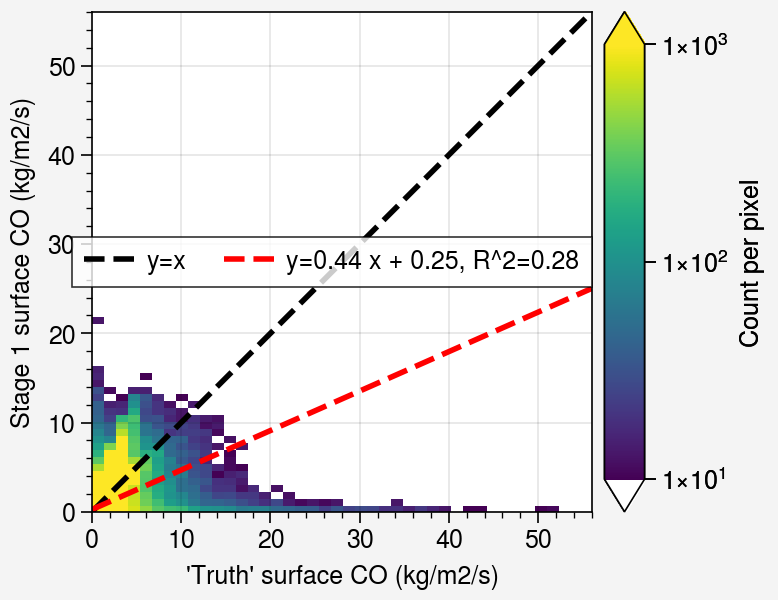

In [ ]:
ex_year = 2019
ex_HPC_run = 'Unet_CO_training_0'
ex_date = str(ex_year)+'-05-01'
import unox.plotting as uplt

comp_plot = uplt.plot_true_pred_comp(
        truth_data={'stage':1, 'x_or_y':'y', 'year':ex_year, 'input_path': 'inputfiles_CO'},
        pred_data={'stage':1, 'HPC_run':ex_HPC_run, 'year':ex_year},
        hist_params={'bins':100, 'vmax':1000, 'vmin':10},
        var='CO',
        units='kg/m2/s'
)

The above Graph shows the performance of the Unox model (as it was after being tuned for NOx predictions) on the CO data for the year 2019. It generally overpredicts the amount CO across the map.

/home/dsequeira/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/dsequeira/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/dsequeira/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/home/dsequeira/miniconda3/envs/uplt/lib/python3.9/site-packages/cartopy/mpl/geoaxes.py:403: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate

cb_extend: both


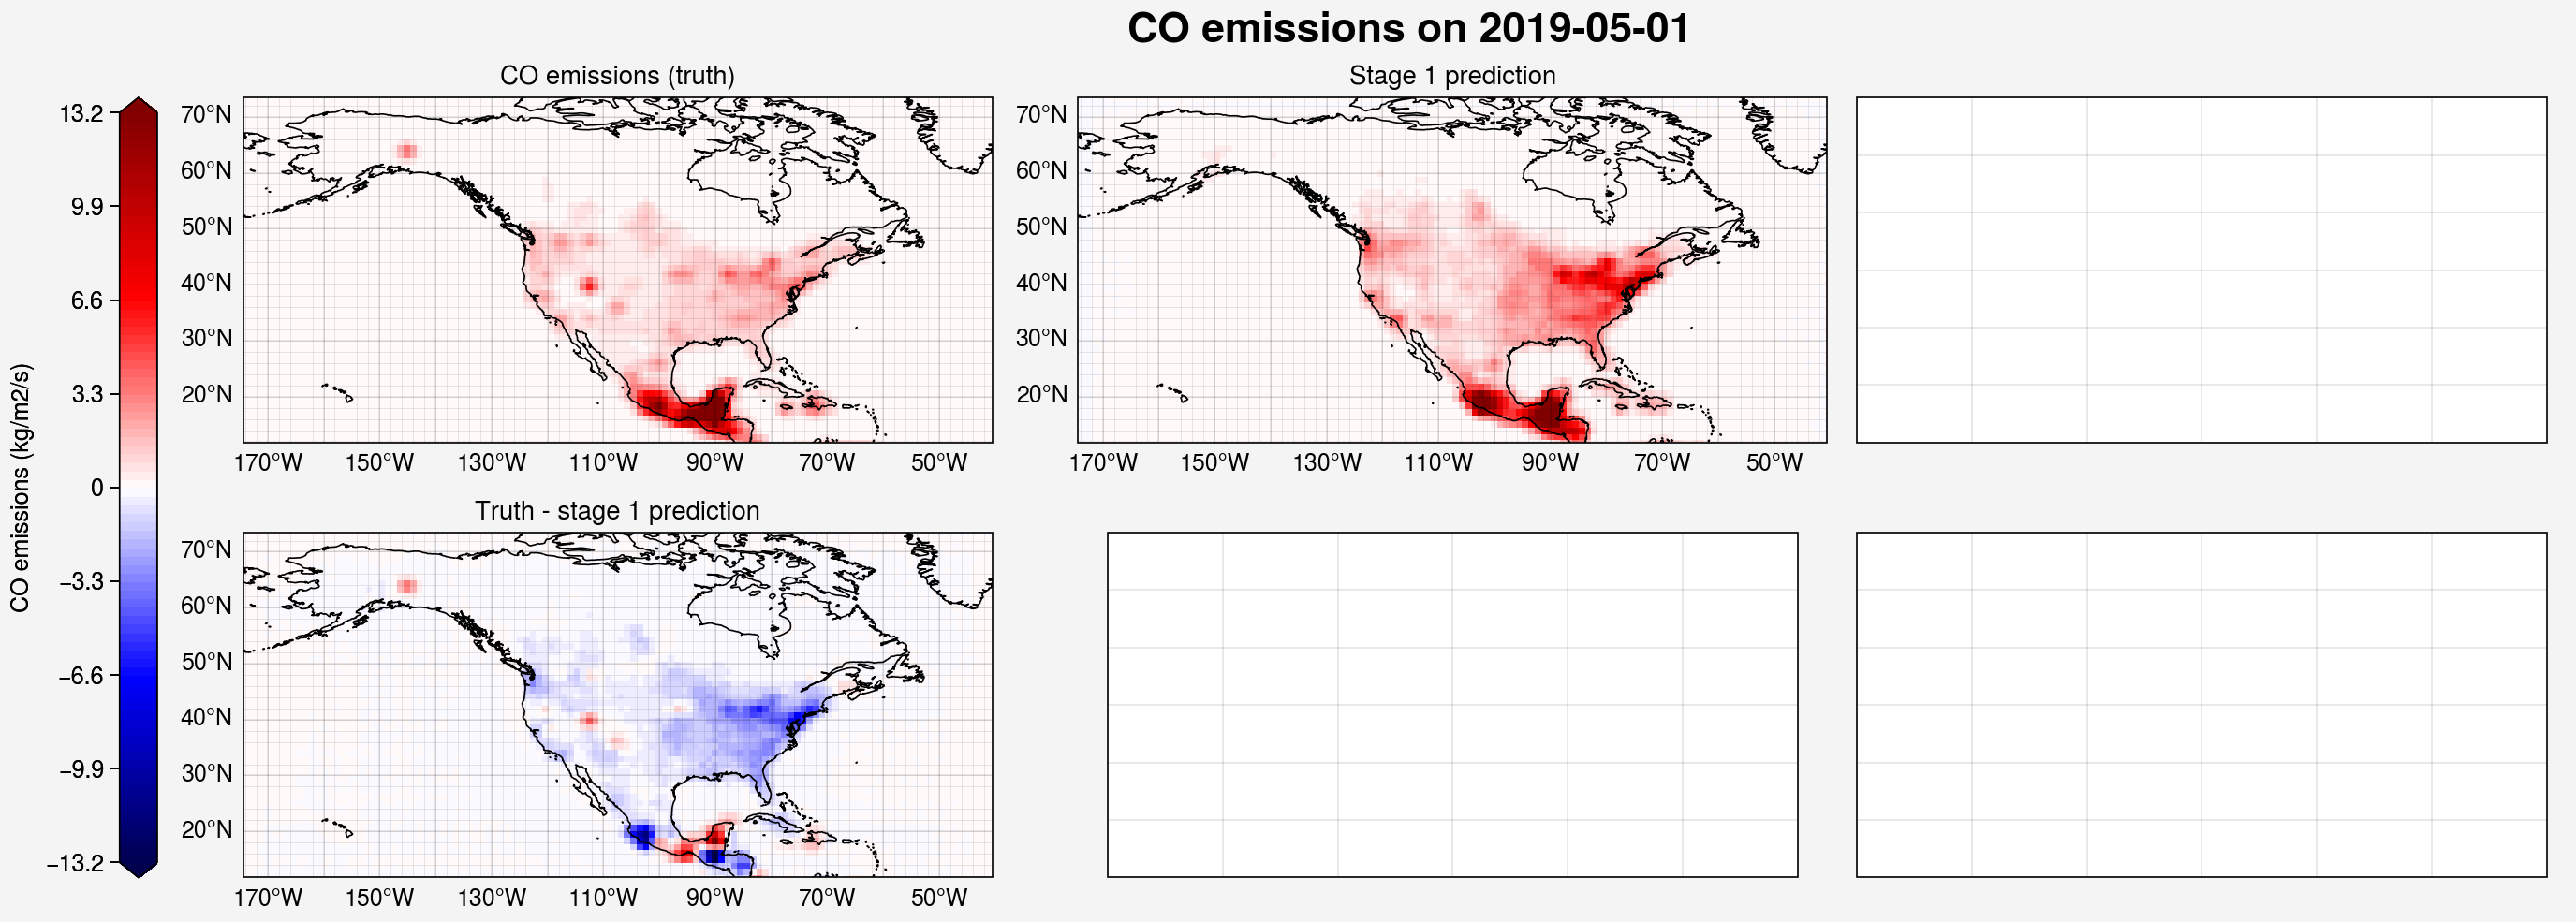

In [ ]:
comp_maps = uplt.plot_stage_comp_maps(
        truth_params={'stage': 1, 'x_or_y': 'y', 'year': ex_year, 'input_path': 'inputfiles_CO'},
        pred_params={'stage': -1, 'HPC_run': ex_HPC_run, 'year': ex_year},
        this_date=ex_date,
        clr_bar_scale=0.1,
        var='CO',
        stage1_only=True,
)

This graph plots the predictions for a day for stage 1. The three empty plots are for when stage 2 is working.

Look at the data and adjust the scaling before plotting by appropriate orders of magnitude.

To optimise we can first try adjusting the scaling factors.

NOx default:

                      scale_factors={'chemra': 1000, # reanalysis data rescaling
                                     'sp': 100000, # surface pressure
                                     'ssrd': 1000000, # surface solar radiation
                                     'blh': 1000}, # Boundary layer height